# CourtListener reference data: EDA

Looks at the outputs of `courtlistener_reference_data.ipynb` to decide what they're good for and what to change before using them.

The scrape parses PDFs with regex, so it isn't perfect. Section 1 checks how much of it is broken, and every section after that only uses the rows that pass. Each section ends with a **takeaway**: what the result means and what to do about it.

| Section | Question | Feeds into |
|---|---|---|
| 1 | How much of the scrape can be trusted? | cleaning rules in the reference data notebook |
| 2 | How many firms does the data really cover? | the train/test split |
| 3 | What do real entries look like? | the next synthetic data version |
| 4 | Which draft rules hold up? | the compliance rules |
| 5 | What do fee examiners flag? | which rules to build next, and how to explain flags |

**Keep in mind:** these are Chapter 11 fee applications. They follow stricter rules than everyday billing and were cleaned up before filing, so they show the polished "after" version of an entry.

## Setup

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

In [2]:
FINAL_DIR = Path("data/final")
ENTRIES_PATH = FINAL_DIR / "time_entries_clean_balanced.csv"
PARAGRAPHS_PATH = FINAL_DIR / "examiner_paragraphs.csv"

# Optional: synthetic entries in the same format, used in sections 3 and 4. Set to None to skip.
SYNTHETIC_PATH = Path("../matching/data/synthetic_time_entries_v2.xlsx")
SYNTHETIC_SHEET = "Time Entries"

SEED = 210

In [3]:
def bar_chart(series, title, xlabel=""):
    """Horizontal bar chart of a Series, largest values on top."""
    data = series.sort_values()
    fig, ax = plt.subplots(figsize=(9, max(2.5, 0.35 * len(data))))
    ax.barh(data.index.astype(str), data.values)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()


def show_examples(df, mask, n=3, col="Narrative", width=150):
    """Prints a few random rows where mask is True."""
    rows = df.loc[mask, col]
    for text in rows.sample(min(n, len(rows)), random_state=SEED):
        print(f"  - {str(text)[:width]}")


def pct(mask):
    """Share of True values, as a percent."""
    return round(mask.mean() * 100, 1)

## Load data

In [4]:
for path in [ENTRIES_PATH, PARAGRAPHS_PATH]:
    assert path.exists(), f"{path} is missing. Run courtlistener_reference_data.ipynb first."

entries = pd.read_csv(ENTRIES_PATH)
entries["Narrative"] = entries["Narrative"].fillna("").astype(str)
entries["words"] = entries["Narrative"].str.split().str.len()

paragraphs = pd.read_csv(PARAGRAPHS_PATH)
paragraphs["category_list"] = paragraphs["categories"].fillna("").str.split(",")

synthetic = None
if SYNTHETIC_PATH is None:
    print("SYNTHETIC_PATH is None. Skipping synthetic comparisons.")
elif not SYNTHETIC_PATH.exists():
    print(f"No file at {SYNTHETIC_PATH.resolve()}. Skipping synthetic comparisons.")
else:
    synthetic = pd.read_excel(SYNTHETIC_PATH, sheet_name=SYNTHETIC_SHEET)

print(f"Time entries:        {len(entries):,} rows from {entries['SOURCE: Case'].nunique()} cases")
print(f"Examiner paragraphs: {len(paragraphs):,} rows from {paragraphs['document_id'].nunique()} reports")
print(f"Synthetic entries:   {'not loaded' if synthetic is None else f'{len(synthetic):,} rows'}")

Time entries:        22,270 rows from 8 cases
Examiner paragraphs: 1,672 rows from 175 reports
Synthetic entries:   640 rows


## 1. How much of the scrape can be trusted?

Each pattern below looks for one kind of parsing problem. Some rows can't be saved (they aren't a single attorney entry). Others are real entries with junk stuck to the front, which is easy to strip.

In [5]:
# Page headers, footers, and summary tables glued onto an entry
TABLE_TEXT = (r"\b(?:total hours|hourly fees|task code description|hours rate|subtotal|fees sorted by"
              r"|time detail|total:|entered:|invoice date:|client/matter:|bill no\.|page \d+ of \d+)")

# "Lastname, Firstname Verb" in the middle of a narrative means two entries ran together
VERBS = ("Review|Reviewed|Draft|Drafted|Call|Attend|Attended|Prepare|Prepared|Revise|Revised|Correspond"
         "|Update|Analyze|Research|Summarize|Meet|Email|Conference|Participate|Discuss|Telephone|Confer")
MERGED = rf"\b[A-Z][a-z]+, [A-Z][a-z]+(?: [A-Z]\.?)? (?:{VERBS})\b"

# Ends on a connecting word, so the rest of the sentence got cut off
CUT_OFF = r"\b(?:in|of|re|the|and|to|with|for|regarding|from|on|a)$"

# Work done by financial advisors or claims agents, not attorneys
ADVISOR = r"\b(?:consultant|tax return|tax compliance|workpaper|forensic|noticing|claims register)\b"

LONG_ENTRY_WORDS = 60   # longer than this is usually several entries or table text

problems = pd.DataFrame({
    "table text": entries["Narrative"].str.contains(TABLE_TEXT, case=False, regex=True),
    "merged entries": entries["Narrative"].str.contains(MERGED, regex=True),
    "cut off": entries["Narrative"].str.strip().str.contains(CUT_OFF, case=False, regex=True),
    "too long": entries["words"] > LONG_ENTRY_WORDS,
    "advisor work": entries["Narrative"].str.contains(ADVISOR, case=False, regex=True),
})

for name in problems.columns:
    print(f"\n{name}: {problems[name].sum():,} rows ({pct(problems[name])}%)")
    show_examples(entries, problems[name])


table text: 576 rows (2.6%)
  - Participation in team call regarding Atlanta Chicago Case: 19-30088 Houston Doc# 3769 Cincinnati Los Angeles New York Cleveland Filed: 08/30/19 Orland
  - Telephone conference with Mr. Layden and Jason I. Ms. Merola regarding research on issues related to the fire victims trust to be formed Atlanta Chica
  - Revise draft of recognition motion per comments from Galaxy (1.0); internal correspondence with Fischer team re: same (0.5). TRIAL MODE − Click here f

merged entries: 172 rows (0.8%)
  - Meeting with A. Turenshine, T. Heyman, T. Weiss, C. Wilson, N. Stern, K. Cooper, S. Lee (Deloitte) to discuss next steps in planning regarding extensi
  - Prepare April 2023 monthly fee statement. McDonald, Carisa Prepare March 2023 monthly fee statement. Verma, Anshu Update fee detail for the period of 
  - Discuss with W. Chan, E. Psaropoulos (Voyager), A. Turenshine, S. Azus, A. Boyd, T. Heyman, T. Weiss, C. Wilson, N. Stern (Deloitte) rebalancing calcu

cut off

Before trusting the counts, skim the examples. If a pattern is catching good entries, loosen it and rerun.

Repeated narratives are checked separately. A few copies of "Document review" is normal, but hundreds of copies of one line would over-represent it.

In [6]:
MAX_COPIES = 5   # keep at most this many copies of the same narrative per case

entries["copy_number"] = entries.groupby(["SOURCE: Case", entries["Narrative"].str.lower().str.strip()]).cumcount() + 1
problems["extra copies"] = entries["copy_number"] > MAX_COPIES

print(f"{problems['extra copies'].sum():,} rows are copies beyond the first {MAX_COPIES} per case\n")
entries["Narrative"].str.lower().str.strip().value_counts().head(8).to_frame("copies")

645 rows are copies beyond the first 5 per case



,copies
Narrative,
quality control for privilege in,132
document review,92
"review document batches assigned to analyst review for responsiveness, privilege and other issues.",68
review various court notices.,50
document review.,44
coordinate document review and production workflows in response to ongoing case team and discovery requests,44
manage qc for privilege in connection with custodial documents relating to the doj/nj/me investigation,27
"monitor, update docket materials and circulate to team.",24


Usable overall: 89.1%


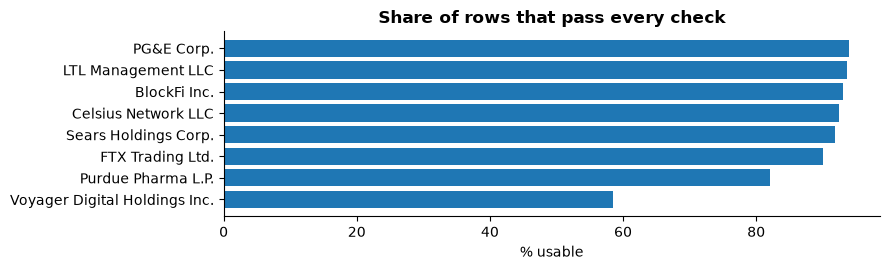

,table text,merged entries,cut off,too long,advisor work,extra copies
SOURCE: Case,,,,,,
BlockFi Inc.,3.0,1.6,0.1,3.0,1.9,2.7
Celsius Network LLC,0.2,0.0,0.3,6.5,0.1,0.7
FTX Trading Ltd.,0.4,0.0,0.0,6.3,1.8,2.4
LTL Management LLC,2.1,0.0,0.3,4.3,0.1,0.5
PG&E Corp.,2.8,0.5,1.2,2.0,0.7,0.0
Purdue Pharma L.P.,1.6,0.0,4.6,2.9,0.2,13.6
Sears Holdings Corp.,2.1,0.3,0.4,4.1,0.4,1.6
Voyager Digital Holdings Inc.,16.4,7.6,17.4,12.8,10.3,0.0


In [7]:
entries["usable"] = ~problems.any(axis=1)

usable_by_case = entries.groupby("SOURCE: Case")["usable"].mean() * 100
print(f"Usable overall: {pct(entries['usable'])}%")
bar_chart(usable_by_case, "Share of rows that pass every check", "% usable")

(problems.groupby(entries["SOURCE: Case"]).mean() * 100).round(1)

Two fixable problems: a U.S. Trustee project category ("Case Administration") or a timekeeper's initials ("MLC") stuck to the front of the narrative.

In [8]:
CATEGORY_HEADINGS = ["Asset Analysis and Recovery", "Asset Disposition", "Asset Sales", "Business Operations",
                     "Case Administration", "Claims Administration and Objections", "Claims Administration",
                     "Employee Benefits/Pensions", "Fee/Employment Applications", "Fee Applications",
                     "Retention / Fee Application", "Financing", "Litigation", "Meetings of Creditors",
                     "Plan and Disclosure Statement", "Relief from Stay", "Tax Issues", "Valuation"]
HEADING_PREFIX = r"^(?:" + "|".join(re.escape(h) for h in CATEGORY_HEADINGS) + r")\s+(?=[A-Z])"
INITIALS_PREFIX = r"^[A-Z]{2,3} (?=[A-Z][a-z])"

for name, pattern in [("category heading", HEADING_PREFIX), ("initials", INITIALS_PREFIX)]:
    mask = entries["Narrative"].str.contains(pattern, regex=True)
    print(f"\n{name} prefix: {mask.sum():,} rows ({pct(mask)}%)")
    show_examples(entries, mask)


category heading prefix: 214 rows (1.0%)
  - Case Administration Attend discussion with UCC, BR to discuss next steps
  - Case Administration Attend committee meeting with R Stark, K Aulet (BR), M Manning, M Meghji (M3), and UCC members re: pending motions, case milestone
  - Case Administration Revisions to the weekly cryptocurrency asset report template at the request of S. Herman

initials prefix: 312 rows (1.4%)
  - JSF Review of Draft NOAT Trust Document in Connection with Plan
  - SC Review and revise Schedule AB, Part 4, Question 15 (.8); Schedules & Schedule AB, Part 7, Question 41 (.4); Schedule AB, Part 10, SOFA Question 65 
  - RCY Additional research and revisions to memo re: statutes of limitation.


In [9]:
# Everything after this point uses the cleaned, usable rows
clean = entries[entries["usable"]].copy()
clean["Narrative"] = (clean["Narrative"]
                      .str.replace(HEADING_PREFIX, "", regex=True)
                      .str.replace(INITIALS_PREFIX, "", regex=True)
                      .str.strip())
clean["words"] = clean["Narrative"].str.split().str.len()
print(f"{len(clean):,} usable rows")

19,850 usable rows


**Takeaway:** about 89% of rows are usable, but it varies a lot by case. Voyager is the worst by far, mostly table text, cut-off entries, and advisor tax work. Purdue loses the most to repeats, since document review teams log the same line over and over. The most repeated line, "Quality control for privilege in", is also cut off, so it's a parsing bug rather than a repetitive biller.

**To do:** move these patterns into `clean_narrative()` and `tag_entry_type()` in the reference data notebook so the exported files are already clean. Rerunning this section afterward should show the problem counts near zero.

## 2. How many firms does the data really cover?

The model split should be grouped by firm, so a model can't do well just by memorizing one firm's writing style. That only works if each firm has one label. `SOURCE: Firm` comes from the filing description, so the same firm appears as "X on behalf of Firm", "Ninth Monthly Fee Statement of Firm", "&" vs "and", and so on.

In [10]:
SUFFIXES = {"llp", "llc", "pllc", "lp", "pc", "pa", "inc", "corp", "co", "ltd", "esq"}


def firm_key(label):
    """Turns a filing label into a cleaned firm name.

    Example: "Daniel Stolz on behalf of Brown Rudnick, LLP" -> "brown rudnick"
    """
    text = str(label).lower()
    text = re.sub(r"^.*?\bon behalf of\s+", "", text)
    text = re.sub(r"^.*?\b(?:statement|application) of\s+", "", text)
    text = text.replace("&", " and ").replace(".", "")
    words = re.sub(r"[^\w\s]", " ", text).split()
    while words and (words[-1] in SUFFIXES or len(words[-1]) == 1):    # drop "LLP", or a cut-off "P"
        words.pop()
    return " ".join(words)


entries["firm_key"] = entries["SOURCE: Firm"].map(firm_key)
clean["firm_key"] = clean["SOURCE: Firm"].map(firm_key)
print(f"Raw labels: {entries['SOURCE: Firm'].nunique()} | cleaned firms: {entries['firm_key'].nunique()}\n")

(entries.groupby("firm_key")["SOURCE: Firm"]
 .agg(labels="nunique", examples=lambda s: " | ".join(s.unique()[:3]))
 .sort_values("labels", ascending=False)
 .head(8))

Raw labels: 115 | cleaned firms: 73



,labels,examples
firm_key,,
baker and hostetler,16,Baker & Hostetler LLP | Fifth Monthly Fee Statement of Baker & Hostetler LLP | Sixth Monthly Fee Statement of Baker ...
simpson thacher and bartlett,7,Eighth Monthly Fee Statement of Simpson Thacher & Bartlett LLP | Ninth Monthly Fee Statement of Simpson Thacher & Ba...
brown rudnick,4,Daniel Stolz on behalf of Brown Rudnick LLP | Donald W Clarke on behalf of Brown Rudnick LLP | Brown Rudnick LLP
genova burns,3,Daniel Stolz on behalf of Genova Burns LLC | Genova Burns LLC | Donald W Clarke on behalf of Genova Burns LLC
munger tolles and olson,3,"Munger Tolles & Olson LLP | Munger, Tolles & Olson LLP | Monthly Fee Statement of Munger Tolles & Olson LLP"
bailey and glasser,3,Daniel Stolz on behalf of Bailey & Glasser LLP | Arthur Abramowitz on behalf of Bailey & Glasser LLP | Donald W Clar...
quinn emanuel urquhart and sullivan,2,"Quinn Emanuel Urquhart & Sullivan, LLP | QUINN EMANUEL URQUHART & SULLIVAN, LLP"
cravath swaine and moore,2,"Fourth Monthly Fee Statement of Cravath, Swaine & Moore LLP | Cravath, Swaine & Moore LLP"


Some labels are a person's name instead of a firm (the person who filed it). Those can't be tied to a firm from the label alone.

In [11]:
FIRM_WORDS = r"\b(?:llp|llc|pllc|lp|pc|pa|inc|group|partners|law|associates)\b|&|\band\b"

labels = entries["SOURCE: Firm"].str.lower().str.replace(".", "", regex=False)     # "P.C." -> "pc"
entries["firm_unclear"] = ~labels.str.contains(FIRM_WORDS, regex=True)
print(f"{entries['firm_unclear'].sum():,} rows ({pct(entries['firm_unclear'])}%) have a label that doesn't look like a firm\n")
entries.loc[entries["firm_unclear"], "SOURCE: Firm"].value_counts().head(8).to_frame("rows")

1,952 rows (8.8%) have a label that doesn't look like a firm



,rows
SOURCE: Firm,
Paul R,602
Eversheds Sutherland,289
David J,254
Jeffrey M,249
Daniel Stolz on behalf of Otterbourg P,165
Michael D,97
Kevin C,81
Stephen B,46


In [12]:
def top_share(s):
    return round(s.value_counts(normalize=True).iloc[0] * 100, 1)


clean.groupby("SOURCE: Case").agg(
    rows=("Narrative", "size"),
    firms=("firm_key", "nunique"),
    top_firm_share=("firm_key", top_share),
).sort_values("top_firm_share", ascending=False)

,rows,firms,top_firm_share
SOURCE: Case,,,
Sears Holdings Corp.,2754,11,77.9
Voyager Digital Holdings Inc.,742,6,65.4
Celsius Network LLC,2775,8,64.2
PG&E Corp.,2817,17,53.1
BlockFi Inc.,2792,5,47.9
Purdue Pharma L.P.,2461,18,44.2
FTX Trading Ltd.,2701,7,42.9
LTL Management LLC,2808,14,28.0


**Takeaway:** the label cleanup roughly cuts the firm count by a third, and about a fifth of rows have a person's name instead of a firm. Some cases are almost entirely one firm (Lehman is essentially one), so they add volume but not variety.

**To do:**
- Group the split on `firm_key`, not `SOURCE: Firm`. Rows with a person's name each become their own group, which is the safe choice.
- When sampling the balanced file, cap rows per firm as well as per case. Consider adding `firm_key` as a column in the reference data export.

## 3. What do real entries look like?

Every case is written differently, so instead of one average this builds a style profile per case. Synthetic data looks realistic if it lands **inside the range** across cases.

In [13]:
SPLITS = r"\(\s*\d{0,2}\.\d{1,2}\s*\)"                         # per-task time like "(0.4)"
ABBREVIATIONS = r"\b(?:re|w/|tc|t/c|conf|corr|rev|prep|mtg|emails?)\b"


def style_profile(df):
    """A few style measures for a set of entries with Hours and Narrative columns."""
    narr = df["Narrative"].fillna("").astype(str)
    words = narr.str.split().str.len()
    letters = narr.str.replace(r"[^A-Za-z]", "", regex=True)
    hours = pd.to_numeric(df["Hours"], errors="coerce")
    return pd.Series({
        "median words": words.median(),
        "% 3 words or fewer": pct(words <= 3),
        "% all caps": pct((letters != "") & (letters == letters.str.upper())),
        "% multi-task (has ;)": pct(narr.str.contains(";")),
        "% with time splits": pct(narr.str.contains(SPLITS, regex=True)),
        "% with abbreviations": pct(narr.str.contains(ABBREVIATIONS, case=False, regex=True)),
        "median hours": hours.median(),
        "% at .5 or whole hours": pct((hours * 2) % 1 == 0),
    })


by_case = clean.groupby("SOURCE: Case").apply(style_profile, include_groups=False)
by_case.round(1)

,median words,% 3 words or fewer,% all caps,% multi-task (has ;),% with time splits,% with abbreviations,median hours,% at .5 or whole hours
SOURCE: Case,,,,,,,,
BlockFi Inc.,9.0,4.9,47.9,20.8,16.9,40.8,0.7,19.3
Celsius Network LLC,15.0,1.7,0.0,52.3,54.3,54.1,1.2,20.6
FTX Trading Ltd.,14.0,0.9,0.0,37.0,55.0,65.1,0.7,19.4
LTL Management LLC,12.0,1.7,33.5,27.4,20.4,39.6,0.7,16.6
PG&E Corp.,13.0,1.7,9.9,9.8,13.1,26.2,0.9,20.9
Purdue Pharma L.P.,13.0,3.6,19.6,39.9,39.3,49.6,1.3,22.1
Sears Holdings Corp.,13.0,3.6,69.9,38.6,44.6,47.0,0.9,22.8
Voyager Digital Holdings Inc.,16.0,1.6,0.0,51.6,59.6,31.8,1.5,21.7


In [14]:
ranges = pd.DataFrame({
    "lowest case": by_case.min(),
    "highest case": by_case.max(),
    "all real": style_profile(clean),
})

if synthetic is not None:
    ranges["synthetic"] = style_profile(synthetic)
    in_range = ranges["synthetic"].between(ranges["lowest case"], ranges["highest case"])
    ranges["in range?"] = np.where(in_range, "yes", "NO")

ranges.round(1)

,lowest case,highest case,all real,synthetic,in range?
median words,9.0,16.0,12.0,5.0,NO
% 3 words or fewer,0.9,4.9,2.5,15.5,NO
% all caps,0.0,69.9,25.0,3.0,yes
% multi-task (has ;),9.8,52.3,32.8,17.3,yes
% with time splits,13.1,59.6,35.5,0.0,NO
% with abbreviations,26.2,65.1,45.4,24.5,NO
median hours,0.7,1.5,0.9,1.3,yes
% at .5 or whole hours,16.6,22.8,20.2,21.2,yes


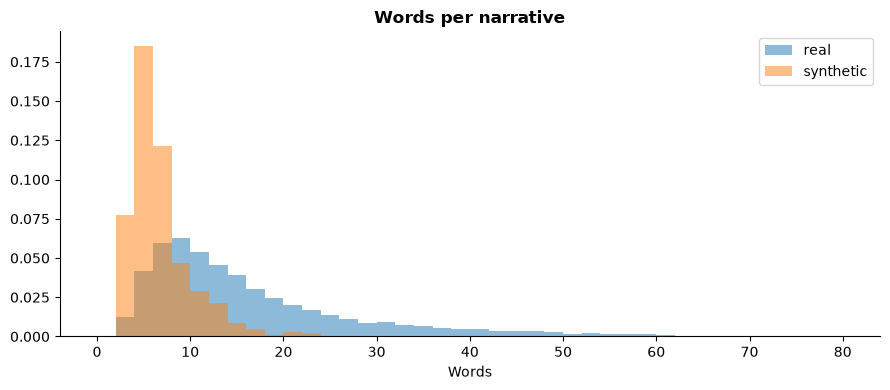

In [15]:
if synthetic is not None:
    fig, ax = plt.subplots()
    ax.hist(clean["words"], bins=40, range=(0, 80), alpha=0.5, density=True, label="real")
    ax.hist(synthetic["Narrative"].fillna("").str.split().str.len(), bins=40, range=(0, 80),
            alpha=0.5, density=True, label="synthetic")
    ax.set_title("Words per narrative")
    ax.set_xlabel("Words")
    ax.legend()
    plt.tight_layout()
    plt.show()

**Takeaway:** the synthetic narratives fall outside the real range on four measures. They're shorter, more often 3 words or fewer, never use time splits, and use fewer abbreviations than any real case. Caps, multi-task entries, and hours already look realistic.

**To do:** for the next synthetic version, lengthen the typical entry, add time splits to some multi-task entries, and use more shorthand ("re", "conf", "w/"). It's fine for synthetic entries to sit at the rough end of the range, since they stand in for drafts before cleanup. They just shouldn't fall outside it.

## 4. Which draft rules hold up?

Each rule gets two checks:
- **Real filed entries:** these were mostly approved, so a rule that fires on a big share of them would flood reviewers with alerts.
- **Synthetic answer key:** `KEY: Narrative Quality` labels entries VAGUE, BLOCK_BILLED, or SPECIFIC, which shows whether a rule catches what it should and how often it flags good entries.

In [16]:
VAGUE_PHRASES = (r"\b(?:attention to|attend(?:ed)? to|work(?:ed)? on|follow[- ]?up|various|misc(?:ellaneous)?"
                 r"|review(?:ed)? (?:of )?(?:the )?file|case (?:matters|issues)|emails? re same)\b")
INTERNAL_MEETING = r"\b(?:internal|team|office|wip) (?:meeting|call|conference)s?\b"
CLERICAL = r"\b(?:scan(?:ned)?|photocop\w*|bates|organi[sz]e (?:files|documents)|calendar(?:ed)?|binders?)\b"
MAX_HOURS = 10


def apply_rules(df):
    """Returns one True/False column per draft rule."""
    narr = df["Narrative"].fillna("").astype(str)
    hours = pd.to_numeric(df["Hours"], errors="coerce")
    return pd.DataFrame({
        "vague phrase": narr.str.contains(VAGUE_PHRASES, case=False, regex=True),
        "very short": narr.str.split().str.len() <= 3,
        "multi-task, no splits": narr.str.contains(";") & ~narr.str.contains(SPLITS, regex=True),
        "over 10 hours": hours > MAX_HOURS,
        "internal meeting": narr.str.contains(INTERNAL_MEETING, case=False, regex=True),
        "clerical task": narr.str.contains(CLERICAL, case=False, regex=True),
    })


real_hits = apply_rules(clean)
for rule in real_hits.columns:
    print(f"\n{rule}: fires on {pct(real_hits[rule])}% of real entries")
    show_examples(clean, real_hits[rule], width=120)


vague phrase: fires on 9.3% of real entries
  - Review updated draft engagement agreement with Swiss counsel (.2); consider follow up re same (.1); participate in call 
  - Call with co-counsel to determine our advice to the committee on two pending motions. BAG Meeting of the committee repre
  - ATTENTION TO TCC RESPONSES TO MEDIATORS’ REQUESTS

very short: fires on 2.5% of real entries
  - PURD115 Revise resolutions.
  - ATTEND ADVISOR CALL.
  - Address administrative/staffing issues

multi-task, no splits: fires on 3.2% of real entries
  - Review of duplicate First Interim Applications filed by A&P and Skadden; Brief review of Akin Gump's revised first inter
  - Emails with TCC re litigation issues;
  - Attend pre-hearing Chambers conference with Judge Kaplan, et al.; appear at hearing/status conference before Judge Kapla

over 10 hours: fires on 1.2% of real entries
  - Attention to analyzing documents NONB including preparing searches for deposition witness preparation as request

In [17]:
# The synthetic label each rule is meant to catch
RULE_TARGETS = {"vague phrase": "VAGUE", "very short": "VAGUE", "multi-task, no splits": "BLOCK_BILLED"}

rule_check = pd.DataFrame({"% of real entries": real_hits.mean() * 100})

if synthetic is not None:
    syn_hits = apply_rules(synthetic)
    label = synthetic["KEY: Narrative Quality"]
    for rule, target in RULE_TARGETS.items():
        rule_check.loc[rule, "% of target caught"] = syn_hits.loc[label == target, rule].mean() * 100
        rule_check.loc[rule, "% of SPECIFIC flagged"] = syn_hits.loc[label == "SPECIFIC", rule].mean() * 100

rule_check.round(1)

,% of real entries,% of target caught,% of SPECIFIC flagged
vague phrase,9.3,87.9,1.3
very short,2.5,29.7,15.3
"multi-task, no splits",3.2,92.2,8.5
over 10 hours,1.2,NaN,NaN
internal meeting,1.8,NaN,NaN
clerical task,1.3,NaN,NaN


In [18]:
if synthetic is not None:
    for rule, target in RULE_TARGETS.items():
        missed = (label == target) & ~syn_hits[rule]
        print(f"\n{rule}: missed {missed.sum()} {target} entries")
        show_examples(synthetic, missed, n=4, width=100)


vague phrase: missed 11 VAGUE entries
  - REVW CORRESPONDENCE
  - REVIEW DOCS
  - attnd to corporate matters
  - emils re same.

very short: missed 64 VAGUE entries
  - attend to offering matters
  - attend to property acquisition
  - attend to fund formation matters
  - attend to various issues

multi-task, no splits: missed 6 BLOCK_BILLED entries
  - revise NVCA documents per Series A cmts. Separately, prepare charter amendment for Project Kite
  - Prepare sig pckts for Project Kite closing. Separately, revw Northwind cmts to content license
  - prepare Summit Growth capitalization table. Separately, prepare closing checklist for Arcadia
  - Draft lgeal section of Project Wren CIM. Separately, review Brightline LOI & comment


**Takeaway:** the label cleanup cuts the firm count by about a third, and roughly 1 in 11 rows has a person's name instead of a firm. Some cases are mostly one firm (Sears is close to 80%), so they add volume but not much variety.

**To do:**
- Group the split on `firm_key`, not `SOURCE: Firm`. Rows with a person's name each become their own group, which is the safe choice.
- When sampling the balanced file, cap rows per firm as well as per case. Consider adding `firm_key` as a column in the reference data export.

## 5. What do fee examiners flag?

A few big cases wrote most of the reports, so counts here are **by report** instead of by paragraph. Otherwise one case would decide what "matters".

In [19]:
coverage = paragraphs.groupby("case_name").agg(paragraphs=("text", "size"), reports=("document_id", "nunique"))
coverage["% of paragraphs"] = (coverage["paragraphs"] / coverage["paragraphs"].sum() * 100).round(1)
coverage.sort_values("paragraphs", ascending=False)

,paragraphs,reports,% of paragraphs
case_name,,,
Motors Liquidation Company (General Motors),787,84,47.1
Boy Scouts of America,305,45,18.2
Lehman Brothers Holdings Inc.,124,9,7.4
Seadrill Limited,107,2,6.4
FTX Trading Ltd.,103,11,6.2
Celsius Network LLC,60,6,3.6
BlockFi Inc.,54,6,3.2
Voyager Digital Holdings Inc.,51,2,3.1
AMR Corporation (American Airlines),46,1,2.8


Category tags come from keywords anywhere in the paragraph, so a paragraph about rates that mentions "budget" once gets both tags. A tag is treated as the paragraph's actual topic only if its keyword shows up in the first 30 words, usually the heading or opening sentence.

In [20]:
# Copied from courtlistener_reference_data.ipynb. Keep the two in sync.
CATEGORY_KEYWORDS = {
    "vague": ["vague", "insufficient detail", "lacks specificity", "lack of detail", "attention to", "review file"],
    "block_billing": ["block bill", "lumping", "lumped"],
    "time_increments": ["tenth of an hour", "one-tenth", "half-hour increments", "whole-hour increments"],
    "multiple_attendees": ["multiple attendees", "multiple professionals", "more than one professional"],
    "overhead_clerical": ["clerical", "administrative task", "secretarial", "word processing", "summer associate"],
    "billing_activities": ["time records", "preparing invoices", "invoices", "invoicing", "redact", "billing review"],
    "fee_defense": ["defending the fee", "fee dispute", "explaining the fees"],
    "nonworking_travel": ["non-working travel", "nonworking travel", "travel time"],
    "transitory_timekeepers": ["transitory", "transient", "fewer than 15 hours"],
    "seniority_mismatch": ["seniority", "higher billing rate", "less experienced", "lower billing rate"],
    "duplication": ["duplicat", "shadowing", "up to speed", "overlap", "staffing"],
    "rates": ["rate increase", "blended rate", "hourly rates", "customary compensation"],
    "internal_conferences": ["conference entries", "intra-office", "inter-office", "internal conference", "internal meeting"],
    "budget_staffing_plan": ["budget", "staffing plan"],
    "expenses": ["first class", "first-class", "airfare", "car service", "mark-up", "markup", "unsupported expense"],
}
ENTRY_LEVEL = {"vague", "block_billing", "time_increments", "multiple_attendees", "overhead_clerical",
               "billing_activities", "fee_defense", "nonworking_travel", "internal_conferences"}


def main_topics(text, tags, first_n_words=30):
    """Keeps only the tags whose keyword appears near the start of the paragraph."""
    opening = " ".join(str(text).lower().split()[:first_n_words])
    return [tag for tag in tags if any(kw in opening for kw in CATEGORY_KEYWORDS.get(tag, []))]


paragraphs["main_topics"] = [main_topics(t, tags) for t, tags in zip(paragraphs["text"], paragraphs["category_list"])]

tag_check = pd.DataFrame({
    "tagged": paragraphs["category_list"].explode().value_counts(),
    "main topic": paragraphs["main_topics"].explode().value_counts(),
}).fillna(0)
tag_check["% main topic"] = (tag_check["main topic"] / tag_check["tagged"] * 100).round(1)
tag_check.sort_values("% main topic")

,tagged,main topic,% main topic
multiple_attendees,91,16,17.6
expenses,105,19,18.1
fee_defense,5,1,20.0
internal_conferences,22,5,22.7
budget_staffing_plan,102,25,24.5
seniority_mismatch,28,7,25.0
billing_activities,172,46,26.7
transitory_timekeepers,119,33,27.7
nonworking_travel,110,41,37.3
block_billing,337,134,39.8


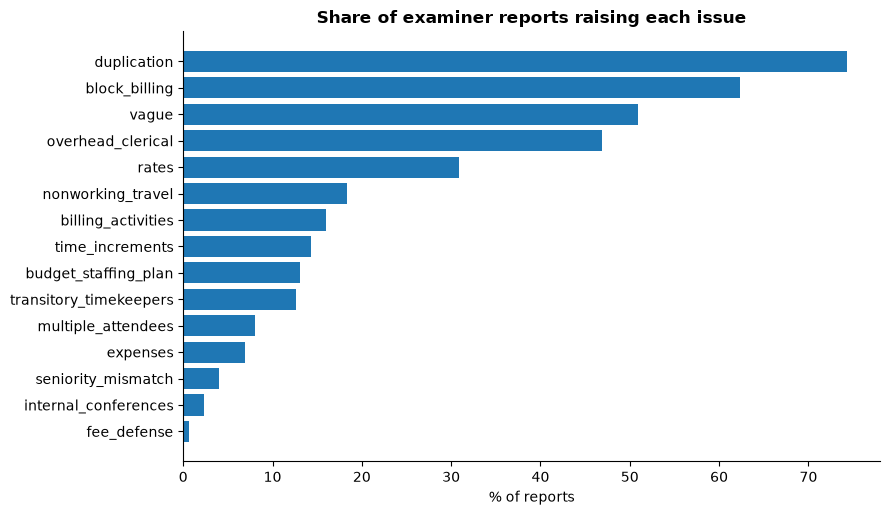

,% of reports,entry level?,draft rule
main_topics,,,
duplication,74.3,no,none yet
block_billing,62.3,yes,"multi-task, no splits"
vague,50.9,yes,vague phrase
overhead_clerical,46.9,yes,clerical task
rates,30.9,no,none yet
nonworking_travel,18.3,yes,none yet
billing_activities,16.0,yes,none yet
time_increments,14.3,yes,none yet
budget_staffing_plan,13.1,no,none yet


In [21]:
# Rules from section 4 that cover each category
CATEGORY_TO_RULE = {"vague": "vague phrase", "block_billing": "multi-task, no splits",
                    "internal_conferences": "internal meeting", "overhead_clerical": "clerical task"}

report_topics = paragraphs[["document_id", "main_topics"]].explode("main_topics").dropna().drop_duplicates()
n_reports = paragraphs["document_id"].nunique()

priority = (report_topics["main_topics"].value_counts() / n_reports * 100).round(1).to_frame("% of reports")
priority["entry level?"] = np.where(priority.index.isin(ENTRY_LEVEL), "yes", "no")
priority["draft rule"] = priority.index.map(CATEGORY_TO_RULE).fillna("none yet")

bar_chart(priority["% of reports"], "Share of examiner reports raising each issue", "% of reports")
priority

How much examiners cut gives a rough sense of how serious each issue is. This pulls percentages from paragraphs about a single topic that also say "reduce", "disallow", or similar.

In [22]:
CUT_WORDS = r"\b(?:reduc|disallow|deduct|cut|recommend)"
PERCENT = r"(\d{1,3}(?:\.\d+)?)\s*(?:%|percent)"

cut_rows = []
for _, row in paragraphs.iterrows():
    if len(row["main_topics"]) != 1 or not re.search(CUT_WORDS, row["text"], flags=re.IGNORECASE):
        continue
    for value in re.findall(PERCENT, row["text"]):
        if 0 < float(value) <= 100:
            cut_rows.append({"topic": row["main_topics"][0], "percent cut": float(value)})

cuts = pd.DataFrame(cut_rows)
cuts.groupby("topic")["percent cut"].agg(["count", "median", "min", "max"]).sort_values("count", ascending=False)

,count,median,min,max
topic,,,,
duplication,48,31.25,7.6,100.0
nonworking_travel,32,50.00,50.0,75.0
vague,27,15.00,15.0,50.0
time_increments,15,53.00,10.0,100.0
overhead_clerical,12,50.00,15.0,100.0
rates,11,25.00,2.7,100.0
block_billing,10,20.00,15.0,30.0
billing_activities,3,1.00,1.0,50.0
expenses,2,10.00,10.0,10.0


A few examiner sentences per topic, to get a feel for the wording behind each flag.

In [23]:
CITATION = r"\b(?:WL \d|F\.\s?(?:2d|3d|4th|Supp)|B\.R\.|U\.S\.C\.|at \*\d)|\d{4}\)"
QUOTED_ENTRY = r"\d{1,2}/\d{1,2}/?\d{2}|[A-Z]{4,} [A-Z]{2,} [A-Z]{2,}"   # time entries quoted from an exhibit

sentence_rows = []
for _, row in paragraphs.iterrows():
    for sentence in re.split(r"(?<=[.;])\s+(?=[A-Z])", row["text"]):
        n_words = len(sentence.split())
        if not 10 <= n_words <= 45 or re.search(CITATION, sentence) or re.search(QUOTED_ENTRY, sentence):
            continue
        for topic in row["main_topics"]:
            if any(kw in sentence.lower() for kw in CATEGORY_KEYWORDS[topic]):
                sentence_rows.append({"topic": topic, "case": row["case_name"], "sentence": sentence.strip()})

sentences = pd.DataFrame(sentence_rows).drop_duplicates("sentence")
for topic in ["vague", "block_billing", "overhead_clerical", "nonworking_travel"]:
    print(f"\n{topic}")
    for text in sentences.loc[sentences["topic"] == topic, "sentence"].sample(3, random_state=SEED):
        print(f"  - {text}")


vague
  - The Fee Examiner’s Confidential Letter Report identified a number of areas of concern, including a potentially excessive number of attendees at hearings, vague entries, and overall staffing on certain matters.
  - In response to concerns about vague entries, many Retained Professionals supplemented their time detail or provided more comprehensive explanations for the work done.
  - Claro has provided revised time entries that resolve the majority of the vague tasks, and all of the incomplete entries.

block_billing
  - The Fee Application contains multiple entries with block billed entries totaling $5,772.80 in fees.
  - Rucki Fee Review identified certain entries that it considers lumped or otherwise not fully compliant with the Local Rules for reasons such as not identifying the counterparties to e- mail discussions, which is not an uncommon practice.
  - Block billing is prohibited by the UST Guidelines at § (b)(4)(v).

overhead_clerical
  - The Fee Examiner identified ch

**Takeaway:**
- The most common issues examiners raise about single entries are block billing, vague descriptions, and clerical work. All three already have a draft rule.
- Non-working travel, billing activities (time spent on invoices), time increments, and multiple attendees come up regularly and have no rule yet.
- Duplication and rates come up often but need the whole fee application, not one entry, so they're out of scope for an entry assistant.
- Typical cuts are modest for vague and block-billed entries and about half for non-working travel. The counts are small, so these are rough.
- Many tags are passing mentions, so use main topics when pulling examples. Older reports (Lehman) have OCR errors, so read sentences before reusing them.
- Some reports quote the exact entries they flagged (often in all caps with dates). Those are real examples of flagged entries, which the synthetic data can't offer.

**To do:** write rules for the entry-level issues with none yet, starting with non-working travel and billing activities. Use the severity to decide what shows as a firm flag vs. a softer suggestion, and use the examiner wording as a starting point for "why was this flagged" explanations. Pulling the quoted entries out of the reports would give a small set of real flagged examples to test rules on.

## Next steps
- **Reference data notebook:** add the section 1 patterns to the cleaning step and add `firm_key` to the export.
- **Model:** group the split on `firm_key`.
- **Synthetic data:** longer typical entries, time splits on some multi-task entries, more shorthand, and labels for meetings, clerical tasks, and long days.
- **Rules:** drop length as a flag, trim the vague phrase list using real hits, and add rules for non-working travel, billing activities, and time increments.